# CME Futures: Feasibility Analysis

Before building a trading strategy it is worth asking whether the data can support one at
all. This notebook does that and nothing else: it fits no model and makes no forecast.

The strategy being checked is described in `config/setup.yaml`. It trades futures contracts
on the Chicago Mercantile Exchange, ranks them once a week, buys the ones that rank highest
and sells the ones that rank lowest. That file says which products it trades, how often it
changes positions, what it assumes trading costs, and how the history is divided between
fitting a model and testing it. This notebook checks each of those assumptions against the
data and reports what it finds.

## Learning objectives

By the end of this notebook you will be able to:

- Count how many contracts are quoted on each date the strategy rebalances, and compare that
  count against the number of positions it has to fill on each side
- Estimate what crossing the bid-ask spread costs, using each contract's own minimum price
  increment as the exchange publishes it rather than a figure inferred from prices
- Read off one chart what fraction of price moves are larger than the cost of trading them
- Measure how long a signal stays informative, and use that to judge whether a weekly
  rebalance is frequent enough to act on it
- Check that a walk-forward split of the history fits the sample available and leaves the
  test period unread

## Book reference

Chapter 6, Sections 6.2-6.6. This notebook reads CME settlement prices, `config/setup.yaml`
and the exchange's contract specifications. It writes nothing.

In [1]:
"""CME Futures Case Study - Feasibility Analysis."""

import re
import warnings

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import yaml
from IPython.display import display
from pandas.tseries.holiday import GoodFriday

from case_studies.utils.feasibility import exceedance_curve, fold_timeline, panel_acf
from data import load_cme_futures
from utils.config import REPO_ROOT
from utils.cv_splits import generate_cv_splits
from utils.paths import get_case_study_dir
from utils.style import COLORS, FIGSIZE, add_message_title

warnings.filterwarnings("ignore")

In [2]:
CASE_STUDY_ID = "cme_futures"
START_DATE = "2011-01-01"
END_DATE = "2025-12-31"

## Configuration

Everything the strategy assumes is declared in `config/setup.yaml`, and this notebook reads
those values rather than repeating them, so the two can never disagree. Four groups of
settings matter here, and each one decides something the sections below test.

**How the history is divided.** The sample runs from 2011 to the end of 2025. The last two
years are the *holdout*: a stretch of history that is not looked at while the strategy is
being designed, so that when it is finally evaluated there, the result is not a rehearsal of
choices already tuned on the same data. Everything computed in this notebook uses the
earlier part, called the development period. `holdout_start` is where the line falls.

**What the strategy trades.** `setup.yaml` names 30 CME products, grouped into seven
sectors. The strategy holds a long side and a short side, and the largest portfolio it will
consider holds 10 products per side, so at least 20 products have to be quoted on any date it
rebalances. That number is the floor Section B.2 tests breadth against; it comes from the
grid of portfolio sizes the strategy will later search over, not from a separate assumption.

**What a trade is assumed to cost.** Crossing the bid-ask spread is charged as a number of
minimum price increments: one for most products, two for the ones `setup.yaml` lists as less
liquid. Section B.3 turns that into a cost that is comparable across products.

**What is being predicted.** The strategy forecasts returns 5 sessions ahead, and a second
variant looks 21 sessions ahead. The 5-session horizon is the primary one, and it sets both
the rebalancing frequency and the gap that has to separate training from validation data.

In [3]:
CASE_DIR = get_case_study_dir(CASE_STUDY_ID)
SETUP = yaml.safe_load((CASE_DIR / "config" / "setup.yaml").read_text())

HOLDOUT_START = str(SETUP["evaluation"]["holdout_start"])
HOLDOUT_END = str(SETUP["evaluation"]["holdout_end"])
PRIMARY_LABEL = SETUP["labels"]["primary"]
LABEL_BUFFER = SETUP["labels"]["buffer"]
PRODUCT_GROUPS = SETUP["universe"]["product_groups"]
DECLARED_PRODUCTS = sorted(p for g in PRODUCT_GROUPS.values() for p in g)
POSITIONS_PER_SIDE = max(SETUP["backtest"]["sweep"]["top_k_grid"][PRIMARY_LABEL])
BREADTH_FLOOR = 2 * POSITIONS_PER_SIDE
SPREAD_TICKS = SETUP["costs"]["spread_ticks"]
ILLIQUID = set(SETUP["costs"]["illiquid_products"])
LABELS = [PRIMARY_LABEL, *SETUP["labels"]["variants"]]
HORIZONS = sorted(int(re.search(r"(\d+)d$", name).group(1)) for name in LABELS)
PRIMARY_HORIZON = int(re.search(r"(\d+)d$", PRIMARY_LABEL).group(1))

print(f"Sample: {START_DATE} to {END_DATE}")
print(f"  Development period, used everywhere below:  {START_DATE} to {HOLDOUT_START}")
print(f"  Holdout, not read by this notebook:         {HOLDOUT_START} to {HOLDOUT_END}")
print(f"Universe: {len(DECLARED_PRODUCTS)} products in {len(PRODUCT_GROUPS)} sectors")
print(
    f"  Up to {POSITIONS_PER_SIDE} positions long and {POSITIONS_PER_SIDE} short, so at least "
    f"{BREADTH_FLOOR} products must be quoted to fill both sides"
)
print(
    f"Assumed spread: {SPREAD_TICKS['liquid']} minimum price increment for most products, "
    f"{SPREAD_TICKS['illiquid']} for the {len(ILLIQUID)} listed as less liquid"
)
print(
    f"Forecast horizons: {' and '.join(f'{h} sessions' for h in HORIZONS)} ahead; "
    f"{PRIMARY_HORIZON} sessions is the primary horizon and sets the rebalancing frequency"
)

Sample: 2011-01-01 to 2025-12-31
  Development period, used everywhere below:  2011-01-01 to 2024-01-01
  Holdout, not read by this notebook:         2024-01-01 to 2025-12-31
Universe: 30 products in 7 sectors
  Up to 10 positions long and 10 short, so at least 20 products must be quoted to fill both sides
Assumed spread: 1 minimum price increment for most products, 2 for the 3 listed as less liquid
Forecast horizons: 5 sessions and 21 sessions ahead; 5 sessions is the primary horizon and sets the rebalancing frequency


## A. Orientation

### What a futures contract is

A futures contract is an agreement to buy or sell a fixed quantity of something - a barrel of
oil, a bushel of corn, a basket of shares - on a fixed date in the future, at a price agreed
today. The Chicago Mercantile Exchange lists such contracts on stock indices, interest rates,
energy, metals, currencies, crops and livestock, and it stands between every buyer and seller
as the clearing house. That is what makes a portfolio like this one practical: a position in
corn and a position in gold are the same kind of instrument, traded the same way, with the
same counterparty.

Each product is listed for several delivery months at once. The contract closest to delivery
is the **front month**, and it is the one this strategy trades, because it is where almost all
the trading happens. It expires, so a position held longer than a few weeks has to be closed
and reopened in the next delivery month. That is called **rolling**.

### Why the roll matters, and what carry is

Rolling is not free, and its cost or benefit is visible in advance. If the next delivery month
trades above the front month, then each roll sells a cheaper contract and buys a dearer one,
and a long position gives back part of whatever the price itself did. If it trades below, the
roll adds to the return instead. The size and sign of that effect is called **carry**, and the
thing to notice is that it can be read off today's prices without predicting anything.

That is what makes a cross-sectional futures strategy plausible. Ranking 30 products by carry
and holding the top ones against the bottom ones is a bet on a difference that is already
observable, rather than on the direction of any single market.

### The three questions this notebook asks

1. **Does the universe exist when the strategy trades?** Positions change once a week, so
   enough products have to be quoted on each of those dates to fill both sides.
2. **Is a typical price move worth more than it costs to capture?** Every round trip crosses
   the bid-ask spread twice, and the spread is not the same size for corn as for a stock index.
3. **Is there enough history to evaluate this honestly?** Enough to split into training and
   validation periods several times over, with the holdout left untouched.

## B. Universe and cost feasibility

### B.1 Load the data and look at the universe

The loader returns one row per product, delivery month and trading session. Delivery months
are numbered by distance from expiry, so `tenor == 0` is the front month and `tenor == 1` is
the one behind it. Section B.4 uses both; everything else uses the front month alone.

Two price columns come back, and they answer different questions. `raw_close` is the
settlement price the exchange actually printed, which is what a trade would have been done
at. `adj_close` is *back-adjusted*: each time the series rolls from one delivery month to the
next, the older history is shifted so the jump between the two contracts does not appear as a
price move. Differences of the adjusted series are therefore returns rather than roll
artefacts, which is why it is the one used for measuring moves. It has one property worth
knowing about now: after enough accumulated adjustments the adjusted level can fall to zero or
below, at which point a percentage change computed from it is meaningless. Every division by
it below is guarded for that.

In [4]:
futures = load_cme_futures(start_date=START_DATE, end_date=END_DATE)
front = (
    futures.filter(pl.col("tenor") == 0)
    .select(["product", "session_date", "raw_close", "adj_close"])
    .sort(["product", "session_date"])
)
research = front.filter(pl.col("session_date") < pl.lit(HOLDOUT_START).str.to_date())

missing = sorted(set(DECLARED_PRODUCTS) - set(research["product"].unique().to_list()))
assert not missing, f"declared in setup.yaml but absent from the data: {missing}"
print(
    f"{research['product'].n_unique()} products, {len(research):,} settlements, "
    f"{research['session_date'].min()} to {research['session_date'].max()}"
)

30 products, 98,116 settlements, 2011-01-03 to 2023-12-29


Here is what those 30 products are, and what one contract of each of them commits you to. The
exchange publishes a specification per product, and six of its fields are worth having in
front of you before anything is computed from the prices, because every cost figure in this
notebook is built out of them.

**Contract size.** A futures contract is written on a fixed quantity, and the quoted price is
the price of one unit of that quantity. One corn contract covers 5,000 bushels and corn is
quoted per bushel. One Australian dollar contract covers A$100,000 and is quoted per
Australian dollar. One E-mini S&P 500 contract covers 50 times the index and is quoted in
index points. So the column reads as bushels for corn, as currency units for the Australian
dollar and as dollars per index point for the S&P, and its one job is to turn a quote into an
amount of money.

**Minimum price increment**, or *tick size*. The smallest amount by which a quote may change.
Corn moves in quarter-cents per bushel, the E-mini S&P in quarter index points, the 10-year
Treasury note in 64ths of a percent of face value.

**Tick value.** What one increment is worth on one contract, in dollars, which is the
increment multiplied by the contract size. The exchange publishes it separately, and it is
worth seeing why the two do not always multiply out. Corn's increment is a quarter of a cent
and its contract is 5,000 bushels, so one increment moves the contract by 1,250 - and that is
1,250 cents, not 1,250 dollars, because corn is quoted in cents per bushel. The tick value the
exchange publishes is in dollars, and the table below shows what it comes to. The grains and
the livestock are quoted in cents; the Treasury contracts are quoted as a percentage of face
value rather than as a fraction of it. Either way the quote is in hundredths of the unit the
contract size counts, a factor of 100. Dividing the published tick value into the increment
times the contract size recovers that factor product by product, which is what the cell below
does. Asserting that it comes out at exactly 1 or exactly 100 is what makes the contract
values in the table dollars rather than cents.

**Contract value**, also called the *notional* value. What one contract is worth outright:
the settlement price, converted to dollars per unit, multiplied by the contract size. The
table takes it at one reference date, the last settlement before the holdout period begins,
so that nothing in it depends on data this notebook is not allowed to read. The spread down
that column is the thing to notice: one corn contract is a commitment of about $24,000 and
one NASDAQ-100 contract is a commitment of about $340,000. A cost quoted in dollars per
contract would therefore mean something different in every row, which is why every cost below
is expressed relative to contract value instead.

**Initial margin**, and the leverage that comes with it. Holding a contract does not require
paying its contract value. It requires posting a deposit with the clearing house, which is
settled up or down every day as the price moves. The deposit is a few percent of the contract
value, and the ratio between the two is the leverage the position carries: the 2-year
Treasury note below controls about $206,000 of notes for a deposit of about $1,300. That
ratio is not a measure of how aggressive the position is. The exchange sets the deposit
against how much the contract moves, so the contracts that move least carry the highest
leverage, and the 2-year note at 158 times is closer in daily risk to silver at 8 times than
the two ratios suggest. What it does mean for this strategy is that the capital it has to
fund is a multiple of the deposits, not of the contract values it ranks.

The margin rates used here come from CME's published schedule and are documented under
"Margin Model" in this case study's README, including where they are approximated: the four
equity index contracts share one rate and the four energy contracts share another, which is
why those rows show identical leverage. They give the right order of magnitude for what a
position costs to carry. They are not a quote from a broker.

**Delivery months.** How many contracts a product lists each year, which is how often a
position in it has to be rolled. The energies list all twelve months, so a position held for a
year is rolled twelve times. The currencies, the equity indices and the Treasuries list four,
evenly spaced through the year, so it is rolled four times. The metals, the crops and the
livestock mostly fall between the two, on cycles that follow their delivery and marketing
seasons. Every roll pays the spread twice and
collects or gives up carry, so this column is what turns carry from something earned per roll
into something earned per year.

The last column is the first date on which each product settles in this sample. All of them
are present from the beginning except the E-mini Russell 2000, which arrives in 2017, and that
is what makes the size of the universe a question rather than a constant. Section B.2 takes it
up.

In [5]:
specs = yaml.safe_load((REPO_ROOT / "data/futures/market/futures_specs.yaml").read_text())
unticked = sorted(set(research["product"].unique().to_list()) - set(specs["products"]))
assert not unticked, f"no contract specification for: {unticked}"
listed = {p: specs["products"][p] for p in DECLARED_PRODUCTS}

ticks = pl.DataFrame(
    {
        "product": list(listed),
        "name": [p["name"] for p in listed.values()],
        "contract_size": [int(p["multiplier"]) for p in listed.values()],
        "tick": [p["tick_size"] for p in listed.values()],
        "tick_value": [p["tick_value"] for p in listed.values()],
        "margin_pct": [p["initial_margin_pct"] for p in listed.values()],
        "months_listed": [len(p["contract_months"]) for p in listed.values()],
    }
).with_columns(
    (pl.col("tick") * pl.col("contract_size") / pl.col("tick_value")).round(6).alias("quote_scale")
)
scales = set(ticks["quote_scale"].to_list())
assert scales <= {1.0, 100.0}, f"unexpected quote scale, expected 1 or 100: {sorted(scales)}"

sectors = pl.DataFrame(
    {
        "product": [p for g in PRODUCT_GROUPS.values() for p in g],
        "sector": [s for s, g in PRODUCT_GROUPS.items() for _ in g],
    }
)
REFERENCE_DATE = research["session_date"].max()
reference = research.filter(pl.col("session_date") == REFERENCE_DATE)
assert reference.height == len(DECLARED_PRODUCTS), (
    f"{reference.height} of {len(DECLARED_PRODUCTS)} products settle on {REFERENCE_DATE}"
)

universe = (
    reference.select("product", "raw_close")
    .join(ticks, "product")
    .join(sectors, "product")
    .join(research.group_by("product").agg(pl.col("session_date").min()), "product")
    .with_columns(
        (pl.col("raw_close") / pl.col("quote_scale") * pl.col("contract_size")).alias("value")
    )
    .with_columns(
        pl.col("value").round().cast(pl.Int64).alias("contract_value_usd"),
        (pl.col("value") * pl.col("margin_pct")).round().cast(pl.Int64).alias("margin_usd"),
        (1 / pl.col("margin_pct")).round(1).alias("leverage"),
        pl.when(pl.col("months_listed") == 12)
        .then(pl.lit("monthly"))
        .when(pl.col("months_listed") == 4)
        .then(pl.lit("quarterly"))
        .otherwise(pl.format("{} per year", pl.col("months_listed")))
        .alias("delivery_months"),
        pl.col("session_date").alias("first_session"),
    )
    .select(
        "sector",
        "product",
        "name",
        "contract_size",
        "tick",
        "tick_value",
        "contract_value_usd",
        "margin_usd",
        "leverage",
        "delivery_months",
        "first_session",
    )
    .sort(["sector", "product"])
)
print(
    f"Contract values are computed from the settlements of {REFERENCE_DATE}, "
    f"the last session before the holdout begins"
)
with pl.Config(tbl_rows=universe.height, tbl_cols=universe.width, tbl_width_chars=250):
    display(universe)

Contract values are computed from the settlements of 2023-12-29, the last session before the holdout begins


sector,product,name,contract_size,tick,tick_value,contract_value_usd,margin_usd,leverage,delivery_months,first_session
str,str,str,i64,f64,f64,i64,i64,f64,str,date
"""agriculture""","""ZC""","""Corn""",5000,0.25,12.5,23537,1146,20.5,"""5 per year""",2011-01-03
"""agriculture""","""ZL""","""Soybean Oil""",60000,0.01,6.0,28890,2252,12.8,"""8 per year""",2011-01-03
"""agriculture""","""ZM""","""Soybean Meal""",100,0.1,10.0,38610,2178,17.7,"""8 per year""",2011-01-03
"""agriculture""","""ZS""","""Soybeans""",5000,0.25,12.5,64875,2691,24.1,"""7 per year""",2011-01-03
"""agriculture""","""ZW""","""Wheat""",5000,0.25,12.5,31438,2507,12.5,"""5 per year""",2011-01-03
"""currencies""","""6A""","""Australian Dollar""",100000,0.0001,10.0,68265,2131,32.0,"""quarterly""",2011-01-03
"""currencies""","""6B""","""British Pound""",62500,0.0001,6.25,79625,1977,40.3,"""quarterly""",2011-01-03
"""currencies""","""6C""","""Canadian Dollar""",100000,0.00005,5.0,75570,1021,74.0,"""quarterly""",2011-01-03
"""currencies""","""6E""","""Euro FX""",125000,0.00005,6.25,138381,2480,55.8,"""quarterly""",2011-01-03


### B.2 How many products are quoted when the strategy rebalances

The strategy changes positions once a week, at the last settlement of the week. Those are its
**rebalancing dates**, and they are the only dates on which the size of the universe matters.
A single count over the whole sample would hide the question a cross-sectional strategy has to
answer, which is whether the products are all there *at the moment it has to choose between
them*.

Counting on any day of the week would hide it too, and specifically it would hide the worst
cases. The last session of the week is usually a Friday, but on a holiday week it is a
Thursday, and holidays are exactly when a settlement file carries only part of the universe.
So the count below is taken on the week's final session, whichever weekday that turns out to
be, and compared against the 20 products the largest portfolio needs.

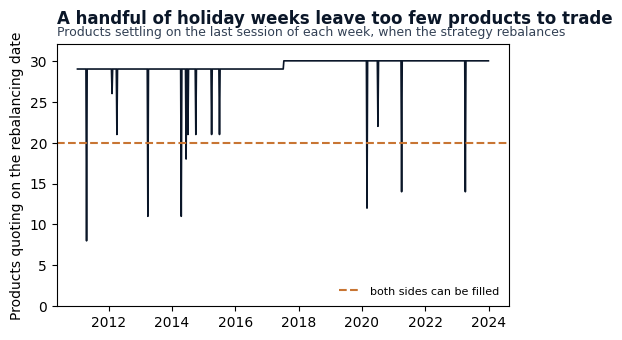

In [6]:
decisions = research.group_by(pl.col("session_date").dt.truncate("1w")).agg(
    pl.col("session_date").max().alias("decision_date")
)
breadth = (
    research.join(decisions, left_on="session_date", right_on="decision_date")
    .group_by("session_date")
    .agg(pl.col("product").n_unique().alias("n_products"))
    .sort("session_date")
)

fig, ax = plt.subplots(figsize=FIGSIZE["single"])
ax.plot(breadth["session_date"], breadth["n_products"], color=COLORS["blue"], linewidth=1.2)
ax.axhline(BREADTH_FLOOR, color=COLORS["copper"], ls="--", lw=1.5, label="both sides can be filled")
ax.set_ylim(0, len(DECLARED_PRODUCTS) + 2)
ax.set_ylabel("Products quoting on the rebalancing date")
ax.legend(frameon=False, fontsize=8, loc="lower right")
add_message_title(
    ax,
    "A handful of holiday weeks leave too few products to trade",
    subtitle="Products settling on the last session of each week, when the strategy rebalances",
)
plt.show()

### B.3 What crossing the spread costs, and what a move is worth

A trade pays the difference between the price at which someone will sell and the price at
which someone will buy - the bid-ask spread - and it pays it twice, once entering and once
leaving. `setup.yaml` assumes that spread is one minimum price increment wide for most
products and two for the less liquid ones, which is the usual assumption for a market where
the front month trades almost continuously.

Turning that assumption into a cost needs the increment itself, and it is taken from the
exchange's published contract specification rather than inferred from the settlement prices.
The reason is visible in the data: some products print settlement prices that do not sit on
their own increment grid, because a settlement is a calculated end-of-session value rather
than a trade. Inferring the increment from those prints would produce a number smaller than
the exchange's, and would therefore charge the strategy less than a real trade would pay. The
products where this happens are listed below.

In [7]:
between = (
    research.join(ticks, "product")
    .with_columns((pl.col("raw_close") / pl.col("tick")).alias("in_ticks"))
    .with_columns((pl.col("in_ticks") - pl.col("in_ticks").round()).abs().alias("offset"))
    .filter(pl.col("offset") > 1e-6)  # a price on the grid divides exactly, to ~1e-12
    .group_by("product")
    .agg(pl.col("offset").min())
    .sort("product")
)
print(
    f"{between.height} of {research['product'].n_unique()} products settle off their own "
    f"increment grid ({', '.join(between['product'])}), the smallest offset "
    f"{between['offset'].min():.2f} of an increment"
)

3 of 30 products settle off their own increment grid (6A, 6S, ZT), the smallest offset 0.50 of an increment


With the increment fixed by the specification, the assumed spread becomes a cost in basis
points of contract value, one figure per product. A basis point is one hundredth of one
percent, and expressing the cost this way is what makes corn comparable with a stock index.

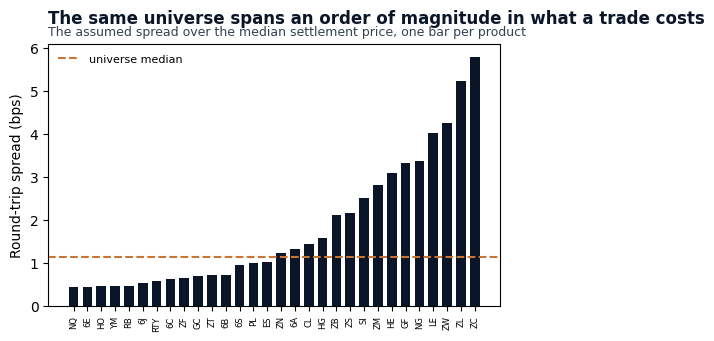

In [8]:
illiquid, liquid = SPREAD_TICKS["illiquid"], SPREAD_TICKS["liquid"]
spread = pl.when(pl.col("product").is_in(ILLIQUID)).then(illiquid).otherwise(liquid)
cost = (
    research.group_by("product")
    .agg(pl.col("raw_close").median().alias("price"))
    .join(ticks, "product")
    .with_columns((spread * pl.col("tick") / pl.col("price") * 1e4).alias("spread_bps"))
    .sort("spread_bps")
)
COST_BPS = float(cost["spread_bps"].median())

fig, ax = plt.subplots(figsize=FIGSIZE["single"])
ax.bar(cost["product"], cost["spread_bps"], color=COLORS["blue"], width=0.7)
ax.axhline(COST_BPS, color=COLORS["copper"], ls="--", lw=1.5, label="universe median")
ax.set_ylabel("Round-trip spread (bps)")
ax.tick_params(axis="x", labelsize=6, rotation=90)
ax.legend(frameon=False, fontsize=8)
add_message_title(
    ax,
    "The same universe spans an order of magnitude in what a trade costs",
    subtitle="The assumed spread over the median settlement price, one bar per product",
)
plt.show()

Because those costs differ by an order of magnitude, a single cost line drawn across raw
returns would answer the question for no product in particular: a move that clears the spread
on a stock index need not clear it on corn. Each move is therefore divided by its own
product's spread before anything is compared. On that scale the break-even point is 1 for
every product, whatever its own cost happens to be.

The chart below reads from the right: for each multiple on the horizontal axis, the curve
gives the fraction of moves at least that large. Where it crosses the line at 1 is the
fraction of moves that are bigger than the cost of trading them.

One thing this chart is not. It is the distribution of how far prices move, measured over
every product and every session in the development period, ignoring direction. It is not the
return a strategy would earn: nothing here is signed, nothing waits a day to enter, and
nothing is restricted to the rebalancing dates. Whether the strategy can pick which moves to
be on the right side of is the question Chapter 7 onwards asks. This is only whether the moves
are large enough to be worth trying.

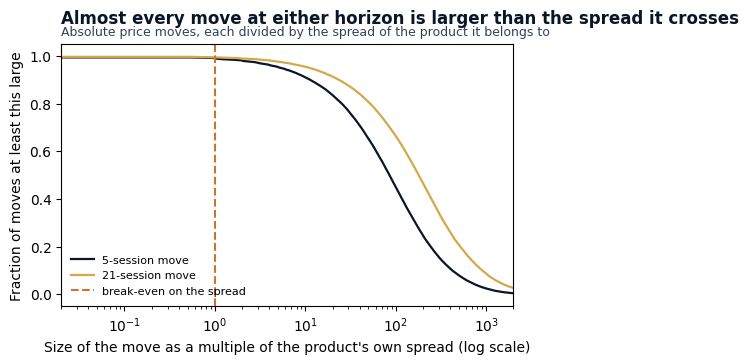

In [9]:
returns = (
    research.with_columns(
        pl.when(pl.col("adj_close").shift(h).over("product") > 0)
        .then(pl.col("adj_close").pct_change(h).abs().over("product"))
        .alias(f"h{h}")
        for h in HORIZONS
    )
    .join(cost.select("product", "spread_bps"), "product")
    .with_columns(pl.col(f"h{h}") * 1e4 / pl.col("spread_bps") for h in HORIZONS)
)

fig, ax = plt.subplots(figsize=FIGSIZE["single"])
for h, color in zip(HORIZONS, (COLORS["blue"], COLORS["amber"]), strict=True):
    multiple, fraction = exceedance_curve(returns[f"h{h}"].drop_nulls().to_numpy())
    ax.plot(multiple, fraction, color=color, lw=1.6, label=f"{h}-session move")
ax.axvline(1, color=COLORS["copper"], ls="--", lw=1.5, label="break-even on the spread")
ax.set_xscale("log")
ax.set_xlim(0.02, 2_000)
ax.set_xlabel("Size of the move as a multiple of the product's own spread (log scale)")
ax.set_ylabel("Fraction of moves at least this large")
ax.legend(frameon=False, fontsize=8, loc="lower left")
add_message_title(
    ax,
    "Almost every move at either horizon is larger than the spread it crosses",
    subtitle="Absolute price moves, each divided by the spread of the product it belongs to",
)
plt.show()

### B.4 How long the carry signal stays informative

Rebalancing every week is only worth its turnover if what the data says on one rebalancing
date still says something by the next. If the ranking were to change completely between
Fridays, the strategy would be paying to trade on noise.

The quantity the ranking reads is carry, and it is measured here as the slope of the term
structure: the price of the second delivery month relative to the front month. A positive
slope means the next contract is dearer, so each roll costs the long position something.

The question "how long does this stay informative" is answered by an **autocorrelation**: the
correlation between the slope today and the slope some number of sessions later. Plotted
against the number of sessions, it shows how quickly the signal loses its relationship to its
own past. What matters for the design is where it sits at 5 sessions, which is one
rebalancing interval.

The correlation is computed inside each product and then averaged across products. The
shortcut of stacking all 30 products into one long series and correlating that returns a
number too, and the number is wrong: at each of the 29 points where one product's history
ends and the next begins, it compares gold with copper. The shaded band shows how much the
result varies from product to product, and the
grey band around zero shows how large a correlation could plausibly be if the slope carried no
information at all.

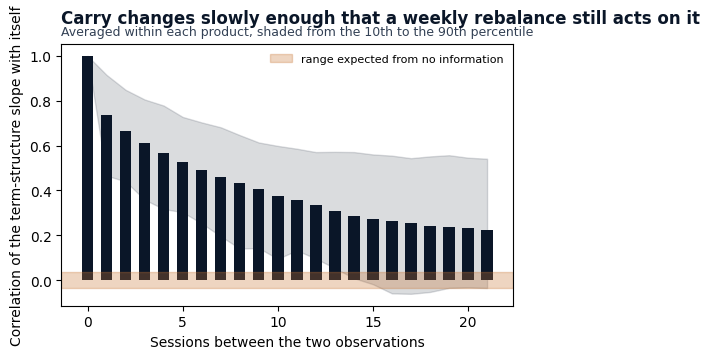

In [10]:
research_window = pl.col("session_date") < pl.lit(HOLDOUT_START).str.to_date()
term = (
    futures.filter((pl.col("tenor") <= 1) & research_window)
    .pivot(on="tenor", index=["product", "session_date"], values="raw_close")
    .rename({"0": "near", "1": "deferred"})
    .drop_nulls()
    .filter(pl.col("near") > 0)
    .sort(["product", "session_date"])
    .with_columns(((pl.col("deferred") - pl.col("near")) / pl.col("near")).alias("slope"))
)
acf = panel_acf(term, entity_col="product", value_col="slope", max_lags=max(HORIZONS))

fig, ax = plt.subplots(figsize=FIGSIZE["single"])
ax.fill_between(acf["lag"], acf["acf_p10"], acf["acf_p90"], color=COLORS["blue"], alpha=0.15)
ax.bar(acf["lag"], acf["acf"], color=COLORS["blue"], width=0.6)
ax.axhspan(
    -acf["band"][0],
    acf["band"][0],
    color=COLORS["copper"],
    alpha=0.3,
    label="range expected from no information",
)
ax.set_xlabel("Sessions between the two observations")
ax.set_ylabel("Correlation of the term-structure slope with itself")
ax.legend(frameon=False, fontsize=8, loc="upper right")
add_message_title(
    ax,
    "Carry changes slowly enough that a weekly rebalance still acts on it",
    subtitle="Averaged within each product, shaded from the 10th to the 90th percentile",
)
plt.show()

### B.5 Move size against cost

Two numbers summarise what the last three sections drew. The first is the median move at the
5-session horizon divided by the median spread, which says how much larger a typical move is
than a typical round trip. The second is the share of moves that beat the spread of their own
product, which is where the curve above crosses its break-even line.

Neither says the strategy clears its total costs. The spread is one component; commission and
the slippage paid on each roll need a position size to compute and arrive with the backtest in
Chapter 16. What these two numbers rule out is the case where the design fails immediately,
because a typical move is smaller than the cost of capturing it.

In [11]:
multiple = pl.col(f"h{PRIMARY_HORIZON}")
median_move_bps, beats_own_spread = (
    returns.drop_nulls(f"h{PRIMARY_HORIZON}")
    .select(
        (multiple * pl.col("spread_bps")).median().alias("mid"),
        (multiple > 1).mean().alias("share"),
    )
    .row(0)
)
print(
    f"Round-trip spread {cost['spread_bps'][0]:.2f} bps on {cost['product'][0]} to "
    f"{cost['spread_bps'][-1]:.2f} bps on {cost['product'][-1]}, median {COST_BPS:.2f} bps"
    f" | median {PRIMARY_HORIZON}-session move {median_move_bps:.1f} bps, ratio "
    f"{median_move_bps / COST_BPS:.0f}x, share beating their own spread {beats_own_spread:.3f}"
)

Round-trip spread 0.43 bps on NQ to 5.80 bps on ZC, median 1.13 bps | median 5-session move 121.2 bps, ratio 107x, share beating their own spread 0.991


The median round-trip spread across the thirty products is 1.13 bps, ranging from 0.43 bps on
the E-mini Nasdaq-100 to 5.80 bps on corn. The median absolute five-session move is 121.2 bps,
roughly a hundred times the median spread, and 0.991 of moves are larger than the spread of
the product on which they occurred.

## C. Design decisions

The three sections above are evidence. This section is where that evidence meets the choices
recorded in `setup.yaml`, and says what each one rests on.

### C.1 How often to rebalance

`setup.yaml` rebalances at the Friday settlement and executes at the Monday open. Section B.3
supports trading at that frequency rather than a slower one: moves at 5 sessions already clear
the spread comfortably, so the choice is not being forced by cost. Section B.4 supports it
from the other side, by showing that carry has not decayed away over the same interval. A
faster cadence would trade more often against a signal that has barely changed; a slower one
would leave part of it unused.

### C.2 What would send this design back

A feasibility study is only useful if some result would have stopped it. The one this notebook
can produce is a cost failure: if the assumed spread were larger than a typical move for most
of the universe, the ranking would be paying more to trade than the move it is trying to
capture, and no model would fix that. Section B.5 is the measurement that would show it.

The other ways this design can fail are strategy outcomes, not properties of the data, and
they are measured where the backtests are. `17_strategy_analysis` asks whether the validation
Sharpe ratio's confidence interval clears zero, and whether the holdout difference against an
equally weighted portfolio of the same products falls entirely below it.

### C.3 What the strategy does with the ranking

`setup.yaml` ranks products by carry and momentum and holds both the top and the bottom of
that ranking. Holding the bottom means selling futures short, which in this market costs
nothing extra: there is no stock to borrow, so a short position is as cheap to carry as a long
one. How much to put in each position is deliberately left open here and settled later by
comparing seven allocation rules - equal notional amounts, amounts proportional to the ranking
score, amounts scaled by each product's recent volatility, and amounts derived from an
estimated covariance matrix.

## D. Walk-forward structure

### D.1 How much evaluation has to spend

A panel of daily prices looks large, but a strategy that acts once a week does not get to use
every row as an independent opportunity. What it spends is rebalancing dates. Three numbers
describe the sample from that point of view: how many sessions there are, how many of them are
rebalancing dates, and how many products are available on a typical one.

In [12]:
print(
    f"Sessions {research['session_date'].n_unique():,} | rebalancing dates {len(decisions):,} "
    f"| products per rebalancing date {breadth['n_products'].mean():.0f}"
)

Sessions 3,357 | rebalancing dates 678 | products per rebalancing date 29


### D.2 The folds

A model is fitted on one stretch of history and evaluated on the stretch that follows it, then
the pair moves forward and the process repeats. Each train-then-validate pair is a **fold**,
and evaluating this way is called **walk-forward**, because the split always runs in the
direction time does.

One detail decides whether the evaluation is honest. The label being predicted is a return 5
sessions ahead, so a training row dated near the end of its block is labelled with a price
that lands after the block ends. Validating on the day immediately after training would score
the model on data it had partly already seen. The fix is to leave a gap between the two, wide
enough to cover the horizon, and the gap is known as **purging**. Its width comes from
`labels.buffer` in `setup.yaml`; the longer 21-session variant declares its own and is split
under it in the later notebooks that use it.

The three assertions below establish what the figure cannot. The gap is a handful of sessions
against training blocks measured in years, so it is too narrow to see; only the assertion can
confirm it is at least as wide as the horizon. The other two check that the number of folds is
the number `setup.yaml` declares, and that no validation window reaches into the holdout. The
figure then draws the boundaries the splitter returned, rather than recomputing them, so the
picture and the folds cannot disagree.

`generate_cv_splits` numbers folds from zero backwards from the most recent, so fold 0 is the last
one before the holdout and the highest number is the earliest. The figure draws them earliest-first
and labels each with that number, which is why the labels count down; every later stage prints
the same ones.

The splitter is given the whole sample, holdout included, and applies the holdout boundary
itself from `evaluation.holdout_start`, which is what every later stage does too. Trimming the
data first would shift the first training date of most folds by a few sessions, and the figure
would then show a training window the pipeline never actually trains on.

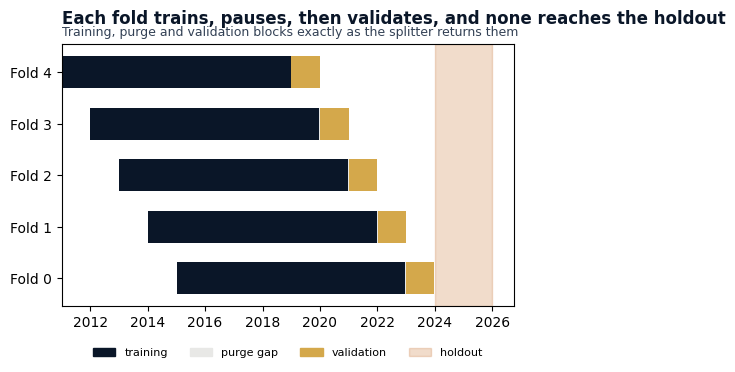

In [13]:
splits = generate_cv_splits(
    front.select("session_date").rename({"session_date": "timestamp"}),
    case_study_id=CASE_STUDY_ID,
    label_buffer=LABEL_BUFFER,
    date_col="timestamp",
)
last_val = max(s["val_end"] for s in splits)
sessions = research["session_date"].unique().sort().to_numpy()
purge = min(int(((sessions > s["train_end"]) & (sessions < s["val_start"])).sum()) for s in splits)
assert len(splits) == SETUP["evaluation"]["n_splits"], "fold count differs from setup.yaml"
assert last_val < np.datetime64(HOLDOUT_START), "a fold reaches into the holdout"
assert purge >= PRIMARY_HORIZON, "the purge gap is narrower than the primary label horizon"

fig, ax = plt.subplots(figsize=FIGSIZE["single"])
fold_timeline(ax, splits, holdout=(HOLDOUT_START, HOLDOUT_END))
add_message_title(
    ax,
    "Each fold trains, pauses, then validates, and none reaches the holdout",
    subtitle="Training, purge and validation blocks exactly as the splitter returns them",
)
plt.show()

## E. What this notebook hands on

Nothing. Which products are tradable is decided by what the exchange lists, and a product
either settles on a given date or it does not, so there is no eligibility rule for a later
notebook to read. The next notebook builds its labels from the same prices this one loaded.

## F. What the evidence says about each setting

One row per setting: the evidence behind it, and the condition under which a reader working on
their own data would choose differently.

| Setting | Evidence | Choose differently when |
|---|---|---|
| `universe.n_products` | B.2, products quoted per rebalancing date | breadth falls below the number of positions the strategy wants on either side |
| `decision.cadence` | B.3 move sizes, B.4 how long carry lasts | moves stop clearing the spread, or carry decays inside one rebalancing interval |
| `costs.spread_ticks` | B.3, the increment per product from the contract specification | the exchange changes an increment, or a product moves between liquidity tiers |
| `evaluation.n_splits` | D.1 rebalancing dates, D.2 fold boundaries | the folds no longer fit the development period |

The breadth chart raises a question it cannot answer on its own. A count that dips below 20 is
only a problem if it happens on ordinary trading days; if it happens on the same holiday every
year, when the settlement file carries only the part of the universe that traded, it is a known
and predictable absence rather than a market that has thinned out. So each date below the floor
is listed with its weekday and whether it is Good Friday. The step upward in the chart is dated
the same way, from the first settlement of the product that joined last, rather than read off
the axis.

In [14]:
listings = (
    research.group_by("product").agg(pl.col("session_date").min().alias("listed")).sort("listed")
)
newest = listings.row(-1, named=True)
modal_before = breadth.filter(pl.col("session_date") < newest["listed"])["n_products"].mode().max()
modal_after = breadth.filter(pl.col("session_date") >= newest["listed"])["n_products"].mode().max()

thin = breadth.filter(pl.col("n_products") < BREADTH_FLOOR).sort("session_date")
good_friday = set(
    GoodFriday.dates(str(breadth["session_date"].min()), str(breadth["session_date"].max())).date
)
thin_lines = "\n".join(
    f"  {d} {d:%a} breadth {n:>2} " + ("Good Friday" if d in good_friday else "regular session")
    for d, n in zip(thin["session_date"], thin["n_products"], strict=True)
)

print(
    f"universe.n_products {SETUP['universe']['n_products']}, products per rebalancing date "
    f"{breadth['n_products'].min()} to {breadth['n_products'].max()}, most often {modal_before} "
    f"before {newest['product']} first settles {newest['listed']} and {modal_after} after\n"
    f"below the floor of {BREADTH_FLOOR} on {thin.height} of {len(breadth)} rebalancing dates, "
    f"{sum(d in good_friday for d in thin['session_date'])} of them Good Friday:\n"
    f"{thin_lines}\n"
    f"decision.cadence {SETUP['decision']['cadence']} | labels.primary {PRIMARY_LABEL}\n"
    f"evaluation.n_splits {SETUP['evaluation']['n_splits']}, generated {len(splits)}, "
    f"last validation ends {last_val.date()}, holdout untouched\n"
    f"labels.buffer {LABEL_BUFFER}, narrowest purge gap {purge} sessions against the "
    f"{PRIMARY_HORIZON}-session primary horizon"
)

universe.n_products 30, products per rebalancing date 8 to 30, most often 29 before RTY first settles 2017-07-10 and 30 after
below the floor of 20 on 7 of 678 rebalancing dates, 5 of them Good Friday:
  2011-04-22 Fri breadth  8 Good Friday
  2013-03-29 Fri breadth 11 Good Friday
  2014-04-18 Fri breadth 11 Good Friday
  2014-06-13 Fri breadth 18 regular session
  2020-02-28 Fri breadth 12 regular session
  2021-04-02 Fri breadth 14 Good Friday
  2023-04-07 Fri breadth 14 Good Friday
decision.cadence weekly_friday_close | labels.primary fwd_ret_5d
evaluation.n_splits 5, generated 5, last validation ends 2023-12-21, holdout untouched
labels.buffer 5D, narrowest purge gap 5 sessions against the 5-session primary horizon


The universe holds 29 products until the E-mini Russell 2000 first settles on 2017-07-10 and
30 after that, falling as low as 8 on one Good Friday. It sits below the floor of 20 on 7 of
678 rebalancing dates: five Good Fridays, and two ordinary Fridays where the settlement file
carries only part of the universe. Five folds are generated, the last validation window ending
2023-12-21, and the narrowest gap between a training block and the validation window that
follows it is 5 sessions, exactly the horizon of the primary label.

## Key takeaways

1. **Count the universe on the dates the strategy actually trades.** A count taken on any day
   of the week averages away the holiday sessions where a two-sided portfolio cannot be
   filled, and those are the sessions that decide whether the design works.
2. **Take the minimum price increment from the contract specification, not from the prices.**
   Settlement prices are calculated values and some of them fall between their own increments,
   so an increment inferred from them understates what a trade really crosses.
3. **Put every product on a common scale before comparing moves to costs.** Dividing each move
   by the spread of its own product puts break-even at 1 everywhere, which one cost line drawn
   across raw returns cannot do when costs differ by an order of magnitude.
4. **Compute a panel autocorrelation inside each entity, then average.** Stacking entities into
   one series measures the joins between them.
5. **Guard every denominator.** A back-adjusted price series can reach zero once the
   accumulated roll adjustments outgrow the price, and a percentage change measured from a
   non-positive base is not a return.

### Known limitations

- Cost here is the bid-ask spread alone. Commission and the slippage paid on each roll both
  need a position size to compute, and enter with the backtest in Chapter 16.
- The spread is assumed from the contract specification, not measured from quotes. The
  settlement data carries no bid or ask.

**Next**: labels at the declared horizons, built on this development period.